In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import os
os.getcwd()
os.chdir(r"C:\Users\athar\Downloads")
import scipy
from scipy import stats

import numpy as np
from numpy import random
import pandas as pd
import scipy
from scipy import stats

import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import pylab
from pylab import legend #heading, referred as label/scale
from pylab import plot, show, title, xlabel, ylabel 

import scipy
from scipy import stats
from scipy.stats import binom,poisson
from scipy.stats import expon
from scipy.stats import norm,t
from scipy.stats import rv_discrete
from scipy.stats import *
import statsmodels
from statsmodels import stats
from statsmodels.stats import weightstats as ssw
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import chi2
from statsmodels.stats import proportion 
from statsmodels.stats.proportion import proportions_ztest 
from statsmodels.stats import proportion as ssp 
from scipy.stats import chisquare
from scipy.stats import chi2_contingency 
from statsmodels.stats import rates 
from statsmodels.stats.rates import test_poisson
from statsmodels.stats.rates import test_poisson_2indep 

In [13]:
df=pd.read_excel('MetroMart.xlsx')

In [11]:
df=pd.set_option('display.max_columns',None)


1. Do Urban and Rural stores differ in the variability of average customer spend?
2. Does the distribution of UPI usage across the four bins (<40%, 40–50%, 50–60%, >60%) appear uniform?
3. Is there a difference in UPI payment percentage between Urban and Rural stores?
4. Do region and store location jointly influence footfall levels?
5. Do Urban and Rural stores differ in the proportion of stores offering discounts?

In [14]:
df

,Location,Region,Footfall,Avg_Spend,BillingTime_Before,BillingTime_After,MonthlySales,Promotion,Payment_UPI_pct,Payment_Card_pct,SatisfactionScore,Complaints
0,Rural,East,788,500.05,5.36,5.19,82.66,NoDiscount,54.6,17.6,3,3
1,Urban,South,978,580.24,5.06,4.58,121.61,NoDiscount,50.9,41.2,4,3
2,Urban,East,1018,565.95,4.94,4.21,123.26,NoDiscount,47.0,40.8,5,2
3,Urban,North,952,560.86,5.36,4.68,117.76,Discount,43.9,43.7,4,6
4,Rural,North,803,508.40,5.30,4.96,81.81,NoDiscount,58.5,27.5,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,Urban,South,962,610.29,5.11,4.72,130.48,Discount,50.1,37.7,4,1
4996,Urban,West,935,596.24,5.33,5.09,119.56,NoDiscount,47.6,41.3,5,4
4997,Urban,East,979,579.97,5.31,4.88,125.61,Discount,46.5,37.5,5,3
4998,Rural,East,777,510.87,5.27,4.82,82.16,Discount,51.1,18.5,4,10


In [16]:
df.Location.value_counts() #What are number of urban or rural. 

Location
Urban    3254
Rural    1746
Name: count, dtype: int64

In [17]:
pd.crosstab(df.Location,df.Region)

Region,East,North,South,West
Location,,,,
Rural,410,467,445,424
Urban,820,827,785,822


<Axes: xlabel='Region'>

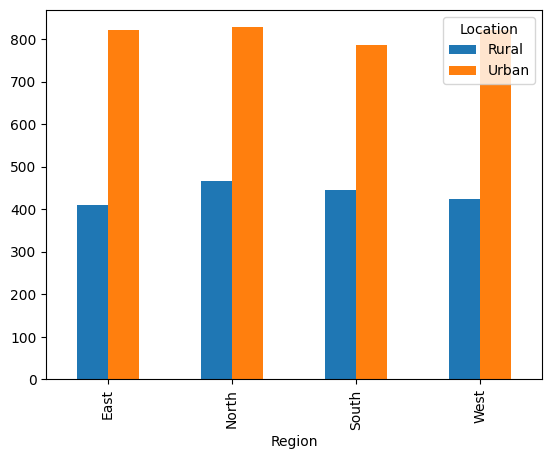

In [19]:
pd.crosstab(df.Region,df.Location).plot(kind='bar')

In [25]:
ind=np.where((df.Region=='South') & (df.Location=='Urban') & (df.Promotion=='Discount'))
len(ind[0])

379

In [31]:
bins=[0,4,9,14,18]
complaint_counts=pd.cut(df.Complaints,bins=bins).value_counts()
complaint_counts

Complaints
(0, 4]      2996
(4, 9]      1681
(9, 14]      143
(14, 18]       3
Name: count, dtype: int64

In [33]:
#1. Do Urban and Rural stores differ in the variability of average customer spend?
rural = df.Avg_Spend.iloc[np.where(df.Location=='Rural')]
urban = df.Avg_Spend.iloc[np.where(df.Location=='Urban')]
f_ts=np.var(rural,ddof=1)/np.var(urban,ddof=1)
p_val = f.cdf(f_ts,len(rural)-1,len(urban)-1)
p_val*2

0.8021795430179787

In [34]:
#2. Does the distribution of UPI usage across the four bins (<40%, 40–50%, 50–60%, >60%) appear uniform?

df.head()

,Location,Region,Footfall,Avg_Spend,BillingTime_Before,BillingTime_After,MonthlySales,Promotion,Payment_UPI_pct,Payment_Card_pct,SatisfactionScore,Complaints
0,Rural,East,788,500.05,5.36,5.19,82.66,NoDiscount,54.6,17.6,3,3
1,Urban,South,978,580.24,5.06,4.58,121.61,NoDiscount,50.9,41.2,4,3
2,Urban,East,1018,565.95,4.94,4.21,123.26,NoDiscount,47.0,40.8,5,2
3,Urban,North,952,560.86,5.36,4.68,117.76,Discount,43.9,43.7,4,6
4,Rural,North,803,508.40,5.30,4.96,81.81,NoDiscount,58.5,27.5,4,2


In [40]:
upi=df.Payment_UPI_pct
upi_cat=pd.cut(upi,bins=[0,40,50,60,100]).value.counts()
upi_cat

AttributeError: 'Series' object has no attribute 'value'

In [ ]:
"""In a single day, how many vada pavs are sold in Mumbai?"""

In [43]:
#4. Do region and store location jointly influence footfall levels?
model=ols("df.Footfall~df.Location*df.Region",df).fit()

In [45]:
tab1=sm.stats.anova_lm(model)
tab1

,df,sum_sq,mean_sq,F,PR(>F)
df.Location,1.0,4.589759e+07,4.589759e+07,28349.775049,0.000000
df.Region,3.0,9.756497e+03,3.252166e+03,2.008780,0.110482
df.Location:df.Region,3.0,4.969605e+03,1.656535e+03,1.023200,0.381114
Residual,4992.0,8.081926e+06,1.618976e+03,NaN,NaN


In [46]:
# 5. Do Urban and Rural stores differ in the proportion of stores offering discounts?
df.head()

,Location,Region,Footfall,Avg_Spend,BillingTime_Before,BillingTime_After,MonthlySales,Promotion,Payment_UPI_pct,Payment_Card_pct,SatisfactionScore,Complaints
0,Rural,East,788,500.05,5.36,5.19,82.66,NoDiscount,54.6,17.6,3,3
1,Urban,South,978,580.24,5.06,4.58,121.61,NoDiscount,50.9,41.2,4,3
2,Urban,East,1018,565.95,4.94,4.21,123.26,NoDiscount,47.0,40.8,5,2
3,Urban,North,952,560.86,5.36,4.68,117.76,Discount,43.9,43.7,4,6
4,Rural,North,803,508.40,5.30,4.96,81.81,NoDiscount,58.5,27.5,4,2


In [62]:
len(np.where((df.Location=='Rural') &(df.Promotion=='Discount'))[0])

893

In [61]:
len(np.where((df.Location=='Rural'))[0])

1746

In [63]:
len(np.where((df.Location=='Urban') &(df.Promotion=='Discount'))[0])

1668

In [64]:
len(np.where((df.Location=='Urban'))[0])

3254

In [71]:
obs=np.array([893,1668])
counts=np.array([1746,3254])

In [72]:
ssp.proportions_ztest(obs,counts,value=0)  #When we want to find percentage, we give value equals zero. 

(-0.07722492189637271, 0.9384446160379812)

In [80]:
#Is the average monthly salary in lakhs across stores greater than 95? 
df.head()
np.mean(df.MonthlySales)

105.70398599999999

In [81]:
ssw.ztest(df.MonthlySales,value=95,alternative='smaller')

(34.986246048122105, 1.0)

In [84]:
np.mean(df.MonthlySales)+1.645*np.std(df.MonthlySales,ddof=1)/len(df.MonthlySales)**0.5 #to find upper bound.  1.645 is the value of norm.ppf(0.05)

106.2072711179798

In [87]:
#Has the new billing software reduced billing time per customer? 
#H0: average billing time before - billing time after ≥ 0 
ssw.ttost_ind(df.BillingTime_Before,df.BillingTime_After,low=0.7,upp=0.7)

(1.0,
 (-38.26309916040145, 1.0, 9998.0),
 (-38.26309916040145, 2.2815018525232555e-299, 9998.0))

In [85]:
df.head()

,Location,Region,Footfall,Avg_Spend,BillingTime_Before,BillingTime_After,MonthlySales,Promotion,Payment_UPI_pct,Payment_Card_pct,SatisfactionScore,Complaints
0,Rural,East,788,500.05,5.36,5.19,82.66,NoDiscount,54.6,17.6,3,3
1,Urban,South,978,580.24,5.06,4.58,121.61,NoDiscount,50.9,41.2,4,3
2,Urban,East,1018,565.95,4.94,4.21,123.26,NoDiscount,47.0,40.8,5,2
3,Urban,North,952,560.86,5.36,4.68,117.76,Discount,43.9,43.7,4,6
4,Rural,North,803,508.40,5.30,4.96,81.81,NoDiscount,58.5,27.5,4,2


In [ ]:
# Do stores in the North and South region differ in their every monthly sales? 

In [ ]:
#Is the overall average complaint rate across stores equal to 4 complaints per store per month? 

In [ ]:
#Do urban and rural stores differ in their complaint rates? 

In [ ]:
One-Sample T-Test, 
Two-Sample T-Test, 
PAIRED T-Test, 
One-Way ANOVA,
Two-Way ANOVA, 
One-Sample Variance Test, 
Two-Sample Variance Test. 
8. One sample proportion
9. Two sample proportion
10. Chi square for good
11. Chi square for degree of association
12. One sample  poisson
13. Two sample poisson

In [ ]:
To explain these 13 statistical tests clearly, I will use a **single domain**: an **E-commerce Company (let's call it "ShopKart")**.

Imagine you are a Data Scientist at ShopKart. Your job is to analyze sales, customer behavior, and delivery times to make business decisions.

Here is how you would use each test in this specific environment.

---

### Part 1: Testing Averages (Means)
*Focus: Are the numbers (sales, time, price) significantly different?*



[Image of t-test distribution curves]


#### 1. One-Sample T-Test
* **What it does:** Compares the mean of your sample data against a known standard or benchmark.
* **ShopKart Example:** ShopKart promises a "30-minute average delivery time." You collect data on 50 recent deliveries. You use this test to check if the actual average delivery time is significantly different from the promised **30 minutes**.

#### 2. Two-Sample T-Test (Independent T-Test)
* **What it does:** Compares the means of two entirely different (independent) groups.
* **ShopKart Example:** You want to know who spends more money. You take a random sample of **Android App users** and a random sample of **Website users**. You compare the average order value between these two distinct groups.

#### 3. Paired T-Test
* **What it does:** Compares the means of the *same* group at two different times (Before vs. After).
* **ShopKart Example:** You select 100 specific customers. You check their spending in **October**. Then, you give those *same* 100 customers a discount coupon and check their spending in **November**. You compare the specific increase/decrease for each person.

#### 4. One-Way ANOVA (Analysis of Variance)
* **What it does:** Compares the means of **3 or more** groups based on one factor.
* **ShopKart Example:** You want to compare average sales across three different regions: **Mumbai, Delhi, and Bangalore**. Since there are more than two groups, you cannot use a T-test; you use One-Way ANOVA.

#### 5. Two-Way ANOVA
* **What it does:** Compares the means based on **two independent factors** at the same time.
* **ShopKart Example:** You want to see how **Region** (Mumbai/Delhi) AND **Payment Method** (Cash/Card) impact the order amount. This test tells you if Region matters, if Payment Method matters, and if there is an interaction between them.

---

### Part 2: Testing Consistency (Variance)
*Focus: How spread out or erratic is the data?*

#### 6. One-Sample Variance Test (Chi-Square for Variance)
* **What it does:** Checks if the variability (spread) of your data matches a specific standard variance.
* **ShopKart Example:** To ensure quality, the weight of a "1kg rice packet" sold on ShopKart is allowed a variance of **0.05kg**. You sample 50 packets to test if the actual variation in packing is within this allowed limit.

#### 7. Two-Sample Variance Test (F-Test)
* **What it does:** Compares the volatility/spread of two different groups.
* **ShopKart Example:** You hire two different courier companies (BlueDart and Delhivery). Their average delivery time is the same, but you want to know which one is more consistent. You compare the **variance** of their delivery times to see if one is significantly more erratic (unreliable) than the other.

---

### Part 3: Testing Proportions (Percentages)
*Focus: Yes/No, Click/No Click, Buy/Don't Buy.*

#### 8. One Sample Proportion
* **What it does:** Compares a percentage from your sample to a target percentage.
* **ShopKart Example:** The marketing team claims that **10%** of visitors click on the "Sale" banner. You analyze 1,000 visitors and find 80 clicked (8%). You use this test to see if that 8% is statistically significantly different from the claimed 10%.

#### 9. Two Sample Proportion
* **What it does:** Compares percentages between two different groups.
* **ShopKart Example:** You run an A/B test. Group A sees a **Red** "Buy Now" button; Group B sees a **Green** "Buy Now" button. You compare the **conversion rate (proportion)** of Group A vs. Group B to see which color drives more purchases.

---

### Part 4: Chi-Square Tests (Categories)
*Focus: Categorical data (Colors, Brands, Yes/No).*



[Image of chi-square distribution table]


#### 10. Chi-Square Goodness of Fit
* **What it does:** Checks if your observed data matches an expected distribution/theory.
* **ShopKart Example:** Historical data says payment preference is usually: **50% UPI, 30% Card, 20% Cash**. In a recent sale, you observed specific numbers. You use this test to see if the recent payment trends still "fit" that 50-30-20 historical expectation.

#### 11. Chi-Square Test for Independence (Association)
* **What it does:** Checks if two categorical variables are related or independent.
* **ShopKart Example:** You have two columns of data: **Gender** (Male/Female) and **Product Category Bought** (Electronics/Fashion/Home). You use this test to find out: *Is product preference dependent on gender?* (i.e., Do men buy more electronics?)

---

### Part 5: Poisson Tests (Counts/Rates)
*Focus: Rare events or counts over time/space.*

#### 12. One Sample Poisson
* **What it does:** Compares a count or rate to a known standard rate.
* **ShopKart Example:** ShopKart's server usually crashes **2 times per month** (historical average). This month, it crashed 5 times. You use this test to determine if 5 crashes is just bad luck, or if the server stability has statistically worsened.

#### 13. Two Sample Poisson
* **What it does:** Compares counts or rates between two different groups.
* **ShopKart Example:** You have two warehouses (Warehouse A and Warehouse B). You count the number of **defective items** returned from each warehouse per month. You use this test to see if Warehouse A has a significantly higher "defect rate" than Warehouse B.

---

### Summary Table for Quick Revision

| Test Family | Key Question | Data Type |
| :--- | :--- | :--- |
| **T-Tests & ANOVA** | Are the **Averages** different? | Continuous (Money, Time) |
| **Variance Tests** | Is the **Consistency** different? | Continuous (Variance) |
| **Proportion Tests** | Are the **Percentages** different? | Binary (Yes/No, Buy/Not Buy) |
| **Chi-Square** | Do the **Categories** match? | Categorical (Red/Blue, Male/Female) |
| **Poisson** | Are the **Event Counts** different? | Count (Defects, Crashes) |

**Next Step:**
Would you like me to generate a Python script using `scipy.stats` for any one of these examples so you can practice the code before your interview?